In [61]:
import pandas as pd
titanic_df = pd.read_csv('final_titanic_data.csv')
titanic_df.head()

,Survived,Age,SibSp,Parch,Fare,Cabin,PStatus,female,male,Embarked Enc
0,0,22.0,1.0,0.0,7.2500,0,3,0,1,0
1,1,38.0,1.0,0.0,71.2833,1,1,1,0,1
2,1,26.0,0.0,0.0,7.9250,0,3,1,0,0
3,1,35.0,1.0,0.0,53.1000,1,1,1,0,0
4,0,35.0,0.0,0.0,8.0500,0,3,0,1,0


In [62]:
titanic_df.describe()

,Survived,Age,SibSp,Parch,Fare,Cabin,PStatus,female,male,Embarked Enc
count,836.000000,836.000000,836.000000,836.000000,836.000000,836.000000,836.000000,836.000000,836.000000,836.000000
mean,0.379187,28.284689,0.526316,0.368421,31.478284,0.214115,2.344498,0.358852,0.641148,0.358852
std,0.485475,10.875135,1.110872,0.801590,49.787317,0.410452,0.822429,0.479951,0.479951,0.638434
min,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,21.500000,0.000000,0.000000,7.895800,0.000000,2.000000,0.000000,0.000000,0.000000
50%,0.000000,30.000000,0.000000,0.000000,13.645850,0.000000,3.000000,0.000000,1.000000,0.000000
75%,1.000000,35.000000,1.000000,0.000000,30.070800,0.000000,3.000000,1.000000,1.000000,1.000000
max,1.000000,55.000000,8.000000,6.000000,512.329200,1.000000,3.000000,1.000000,1.000000,2.000000


### Handling Data Normalization

1. Min-Max Normalization

In [63]:
min_fare = titanic_df.Fare.min()
max_fare = titanic_df.Fare.max()


In [64]:
norm_fare = (titanic_df.Fare - min_fare) / (max_fare - min_fare)
norm_fare

0      0.014151
1      0.139136
2      0.015469
3      0.103644
4      0.015713
         ...   
831    0.025374
832    0.058556
833    0.045771
834    0.058556
835    0.015127
Name: Fare, Length: 836, dtype: float64

In [65]:
norm_fare.describe()

count    836.000000
mean       0.061442
std        0.097178
min        0.000000
25%        0.015412
50%        0.026635
75%        0.058694
max        1.000000
Name: Fare, dtype: float64

In [66]:
# titanic_df['Fare_Normalized'] = (
#     titanic_df['Fare'] - min_fare
# ) / (
#     max_fare - min_fare
# )

# titanic_df[['Fare', 'Fare_Normalized']].head()

<Axes: ylabel='Density'>

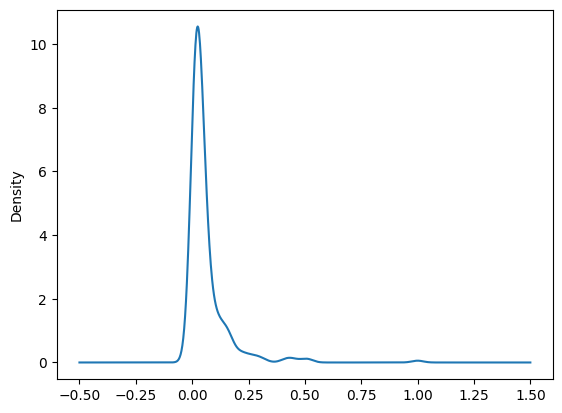

In [67]:
norm_fare.plot(kind='kde')

In [68]:
from sklearn.preprocessing import MinMaxScaler

In [69]:
mm_scaler = MinMaxScaler()

scaled_data = mm_scaler.fit_transform(titanic_df)

In [70]:
pd.DataFrame(scaled_data, columns=titanic_df.columns)

,Survived,Age,SibSp,Parch,Fare,Cabin,PStatus,female,male,Embarked Enc
0,0.0,0.377358,0.125,0.000000,0.014151,0.0,1.0,0.0,1.0,0.0
1,1.0,0.679245,0.125,0.000000,0.139136,1.0,0.0,1.0,0.0,0.5
2,1.0,0.452830,0.000,0.000000,0.015469,0.0,1.0,1.0,0.0,0.0
3,1.0,0.622642,0.125,0.000000,0.103644,1.0,0.0,1.0,0.0,0.0
4,0.0,0.622642,0.000,0.000000,0.015713,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
831,0.0,0.471698,0.000,0.000000,0.025374,0.0,0.5,0.0,1.0,0.0
832,1.0,0.320755,0.000,0.000000,0.058556,1.0,0.0,1.0,0.0,0.0
833,0.0,0.367925,0.125,0.333333,0.045771,0.0,1.0,1.0,0.0,0.0
834,1.0,0.452830,0.000,0.000000,0.058556,1.0,0.0,0.0,1.0,0.5


2. Z-Score Normalization / StandardScaler

In [71]:
mean_fare = titanic_df.Fare.mean()
std = titanic_df.Fare.std()

In [72]:
scaled_fare = (titanic_df.Fare - mean_fare) / std

In [73]:
round(scaled_fare.describe(), 7)

count    836.000000
mean      -0.000000
std        1.000000
min       -0.632255
25%       -0.473664
50%       -0.358172
75%       -0.028270
max        9.658101
Name: Fare, dtype: float64

<Axes: ylabel='Density'>

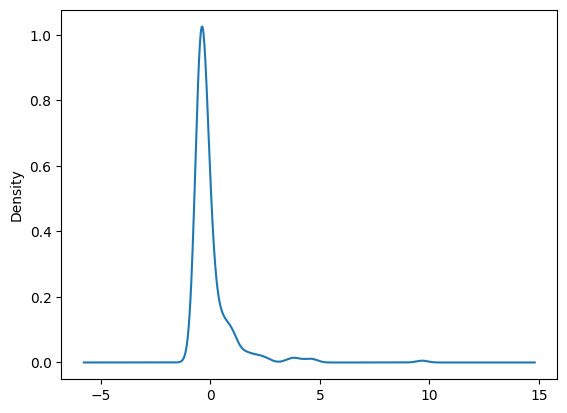

In [74]:
scaled_fare.plot(kind = 'kde')

In [75]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
norm_data = std_scaler.fit_transform(titanic_df)

In [76]:
pd.DataFrame(norm_data, columns=titanic_df.columns)

,Survived,Age,SibSp,Parch,Fare,Cabin,PStatus,female,male,Embarked Enc
0,-0.781531,-0.578241,0.426663,-0.459888,-0.486927,-0.521968,0.797510,-0.748132,0.748132,-0.562417
1,1.279541,0.893886,0.426663,-0.459888,0.799980,1.915826,-1.635768,1.336663,-1.336663,1.004852
2,1.279541,-0.210210,-0.474070,-0.459888,-0.473361,-0.521968,0.797510,1.336663,-1.336663,-0.562417
3,1.279541,0.617862,0.426663,-0.459888,0.434542,1.915826,-1.635768,1.336663,-1.336663,-0.562417
4,-0.781531,0.617862,-0.474070,-0.459888,-0.470849,-0.521968,0.797510,-0.748132,0.748132,-0.562417
...,...,...,...,...,...,...,...,...,...,...
831,-0.781531,-0.118202,-0.474070,-0.459888,-0.371367,-0.521968,-0.419129,-0.748132,0.748132,-0.562417
832,1.279541,-0.854265,-0.474070,-0.459888,-0.029710,1.915826,-1.635768,1.336663,-1.336663,-0.562417
833,-0.781531,-0.624245,0.426663,2.036647,-0.161348,-0.521968,0.797510,1.336663,-1.336663,-0.562417
834,1.279541,-0.210210,-0.474070,-0.459888,-0.029710,1.915826,-1.635768,-0.748132,0.748132,1.004852


##### Day 13

3. Log Transformation
   
Log transformation is a powerful, non-linear data preprocessing technique used to manage highly skewed data, typically when a dataset contains extreme outliers or values spanning multiple orders of magnitude (e.g., income, population, or sales data). It acts as a normalization technique by compressing the right tail of a distribution, effectively reducing skewness and making the distribution more symmetric or normally distributed.

Why Use Log TransformationFixing Right-Skewed Data: 
  
* It is ideal for data where most values are small, but a few are extremely large.Stabilizing Variance: 
* It helps stabilize variance, particularly in cases where the variance increases with the mean.
* Linearizing Relationships: Log transformation can transform non-linear, exponential relationships into linear ones, improving model performance.
* De-emphasizing Outliers: Large values are "compressed" or "shrunk," allowing smaller values to be better represented in models

In [77]:
import numpy as np

# peak = 5 * 10e2
# n = 250         # points per side

# k = np.log(peak)
# growth = np.exp(np.linspace(1, k, n))
# decay = np.growth

4. Power Transformation

<Axes: ylabel='Density'>

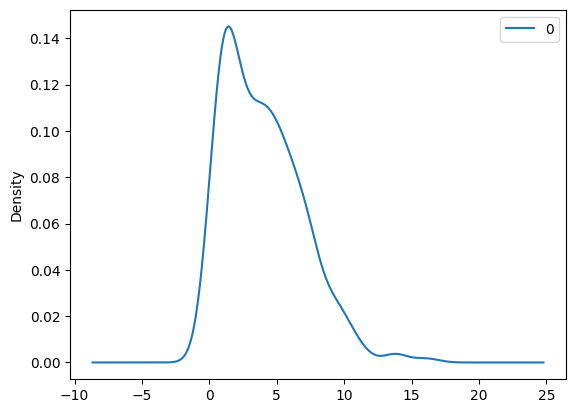

In [78]:
from scipy.stats import skewnorm

data = pd.DataFrame(skewnorm.rvs(25, size = 500, scale = 5))
data.plot.kde()

In [79]:
def power_transform(x, powe_factor = 1):
    return np.sign(x) * np.power(np.abs(x), powe_factor)

<Axes: ylabel='Density'>

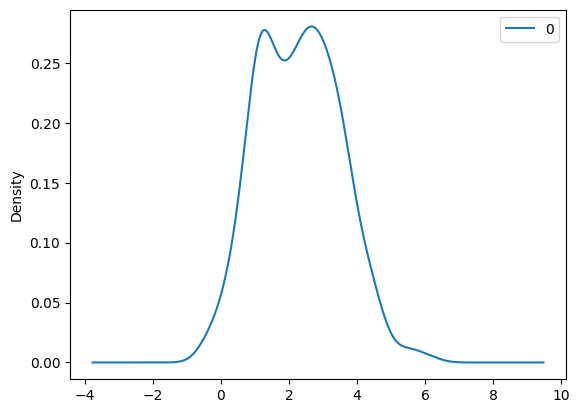

In [80]:
trans_data = power_transform(data, powe_factor = 0.65)
trans_data.plot.kde()